In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve
)

import shap

In [31]:
df = pd.read_csv("telco_churn.csv")
df

,Unnamed: 0,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,0,29.85,29.85,0,True,False,False,True,True,...,False,False,True,False,True,False,False,False,False,False
1,1,0,56.95,1889.50,0,False,True,True,False,True,...,False,False,False,True,False,False,True,False,False,False
2,2,0,53.85,108.15,1,False,True,True,False,True,...,False,False,False,True,True,False,False,False,False,False
3,3,0,42.30,1840.75,0,False,True,True,False,True,...,True,False,False,False,False,False,False,True,False,False
4,4,0,70.70,151.65,1,True,False,True,False,True,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,7038,0,84.80,1990.50,0,False,True,False,True,False,...,False,False,False,True,False,True,False,False,False,False
7028,7039,0,103.20,7362.90,0,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
7029,7040,0,29.60,346.45,0,True,False,False,True,False,...,False,False,True,False,True,False,False,False,False,False
7030,7041,1,74.40,306.60,1,False,True,False,True,True,...,False,False,False,True,True,False,False,False,False,False


In [32]:
# Drop index column
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


# One-hot encoding
df = pd.get_dummies(df, drop_first=False)

# Remove dummy trap
cols_to_drop = [
    "gender_Male", "Partner_No", "Dependents_No", "PhoneService_No",
    "MultipleLines_No", "InternetService_No", "OnlineSecurity_No",
    "OnlineBackup_No", "DeviceProtection_No", "TechSupport_No",
    "StreamingTV_No", "StreamingMovies_No", "Contract_Month-to-month",
    "PaperlessBilling_No", "PaymentMethod_Mailed check"
]

df.drop([col for col in cols_to_drop if col in df.columns], axis=1, inplace=True)

# Convert boolean → int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

C:\Users\Nisarg Shah\AppData\Local\Temp\ipykernel_2984\2587142691.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


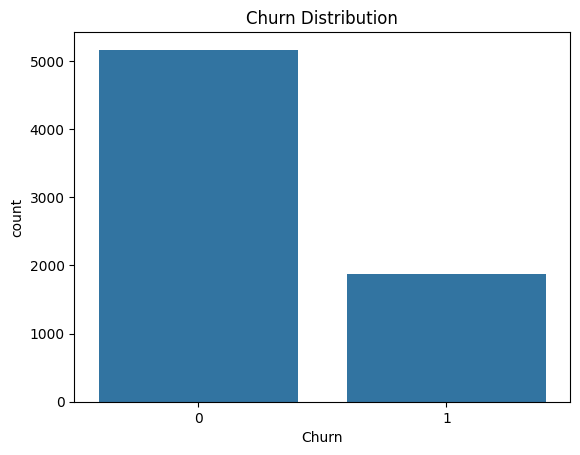

In [33]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [34]:
# Approx tenure (NOTE: midpoint approximation → introduces noise)
df["approx_tenure"] = (
    df.get("tenure_group_13 - 24", 0) * 18 +
    df.get("tenure_group_25 - 36", 0) * 30 +
    df.get("tenure_group_37 - 48", 0) * 42 +
    df.get("tenure_group_49 - 60", 0) * 54 +
    df.get("tenure_group_61 - 72", 0) * 66
)

df.loc[df["approx_tenure"] == 0, "approx_tenure"] = 6

# Avg spend
df["avg_monthly_spend"] = df["TotalCharges"] / df["approx_tenure"]

# Total services
service_cols = [
    "OnlineSecurity_Yes", "OnlineBackup_Yes", "DeviceProtection_Yes",
    "TechSupport_Yes", "StreamingTV_Yes", "StreamingMovies_Yes"
]

df["total_services"] = df[service_cols].sum(axis=1)

### Data Leakage Consideration

TotalCharges is derived from:
- tenure
- MonthlyCharges

Thus, it is highly correlated with both.

Including all three features may introduce redundancy and potential leakage-like effects.
However, since all values are known at prediction time, it is acceptable but should be monitored.

In [35]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [37]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced"))
])

In [38]:
lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:,1]

In [39]:
def evaluate(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [40]:
evaluate(y_test, y_pred_lr)

Accuracy: 0.728500355366027
Precision: 0.49324324324324326
Recall: 0.7807486631016043
F1: 0.6045548654244306
Confusion Matrix:
 [[733 300]
 [ 82 292]]


In [41]:
cv_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring="recall")
print("LR CV Recall:", cv_lr.mean())

LR CV Recall: 0.7926421404682273


In [42]:
rf_model = RandomForestClassifier(random_state=42)

cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="recall")
print("RF CV Recall:", cv_rf.mean())

RF CV Recall: 0.5010033444816053


In [43]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3,
                    scoring="recall")

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [44]:
y_pred_rf = best_rf.predict(X_test)
evaluate(y_test, y_pred_rf)

Accuracy: 0.7839374555792467
Precision: 0.6206896551724138
Recall: 0.48128342245989303
F1: 0.5421686746987951
Confusion Matrix:
 [[923 110]
 [194 180]]


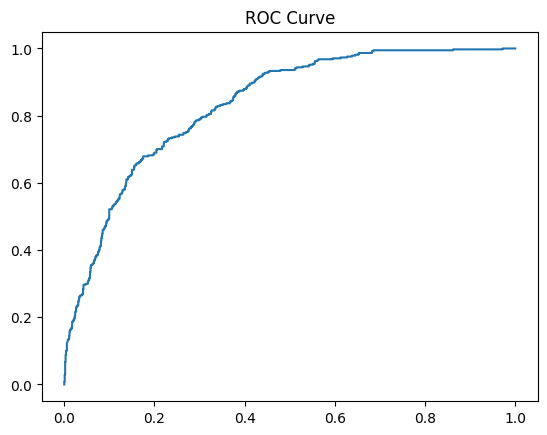

In [45]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

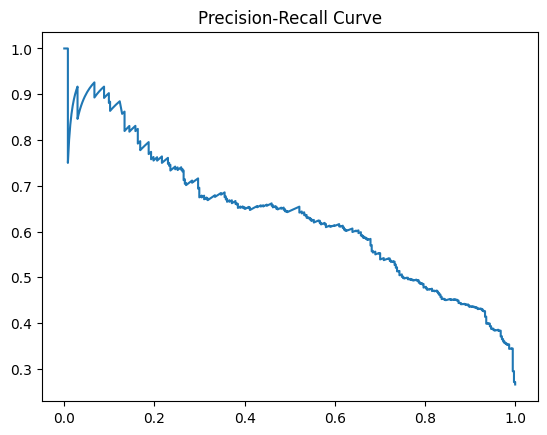

In [46]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()

In [47]:
threshold = 0.3
y_pred_new = (y_prob_lr > threshold).astype(int)

evaluate(y_test, y_pred_new)

Accuracy: 0.6439232409381663
Precision: 0.42303030303030303
Recall: 0.9331550802139037
F1: 0.5821517931609674
Confusion Matrix:
 [[557 476]
 [ 25 349]]


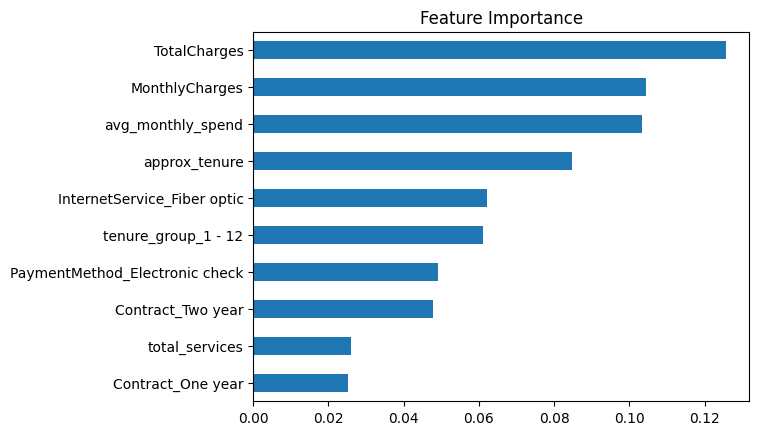

In [48]:
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)

importance.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

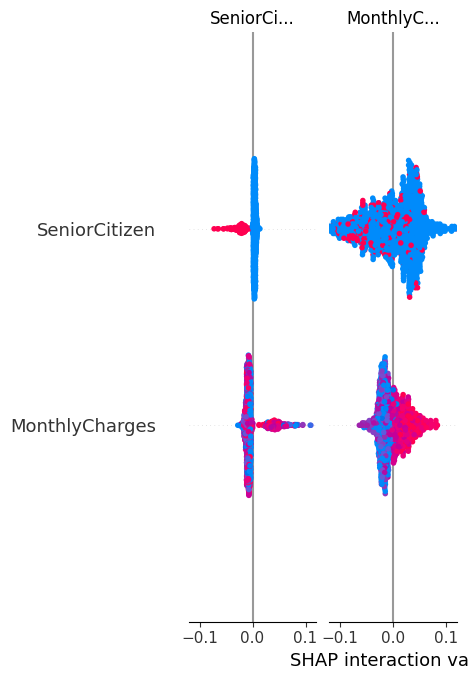

In [49]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# Handle different SHAP versions
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

## Final Insights

- Logistic Regression achieved highest recall (~93% after tuning)
- Random Forest improved precision but missed churn cases
- Key drivers: charges, tenure, payment method
- SHAP confirms importance of pricing and tenure features

## Limitations

- approx_tenure is an approximation (midpoint assumption)
- Feature correlation (TotalCharges, MonthlyCharges, tenure)
- Further tuning and feature engineering can improve performance